In [1]:
# Install Pandas Data Reader
!pip3 install pandas-datareader

Please see https://github.com/pypa/pip/issues/5599 for advice on fixing the underlying issue.
To avoid this problem you can invoke Python with '-m pip' instead of running pip directly.
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 2.3 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: /Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip


In [11]:
# pandas datareader yahoo get_data doesn't work accurately as the endpoints have been changed
# import pandas_datareader.data as web
import yfinance as yf
import pandas as pd
from datetime import datetime

In [17]:
df_tesla = yf.download('TSLA', start='2017-01-01', end='2025-12-05')
# print(data.head())

/var/folders/wz/cnwy77v95fz65y4_p_vs2l140000gn/T/ipykernel_56468/2800111053.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_tesla = yf.download('TSLA', start='2017-01-01', end='2025-12-05')
[*********************100%***********************]  1 of 1 completed


In [21]:
df_tesla.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-01-03,14.466000,14.688667,14.064000,14.324000,88849500
2017-01-04,15.132667,15.200000,14.287333,14.316667,168202500
2017-01-05,15.116667,15.165333,14.796667,15.094667,88675500
2017-01-06,15.267333,15.354000,15.030000,15.128667,82918500
2017-01-09,15.418667,15.461333,15.200000,15.264667,59692500


<AxesSubplot:xlabel='Date'>

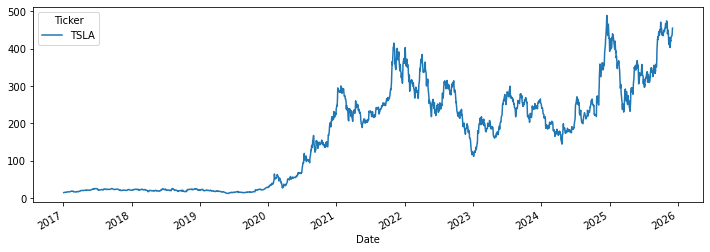

In [24]:
df_tesla['High'].plot(figsize=(12,4))

<AxesSubplot:xlabel='Date'>

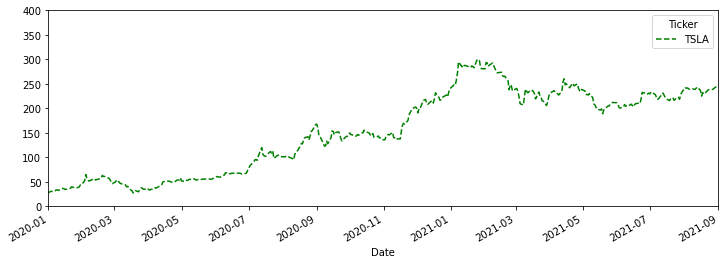

In [29]:
# xlimit and ylimit and coloring
# ls defines the style of line we wantd
df_tesla['High'].plot(xlim=['2020-01-01', '2021-09-01'], ylim=[0, 400], figsize=(12,4), c='green', ls='--')

In [33]:
index = df_tesla.loc['2020-01-01': '2021-09-01'].index
share_open = df_tesla.loc['2020-01-01': '2021-09-01']['Open']

In [37]:
import matplotlib.pyplot as plt
%matplotlib inline

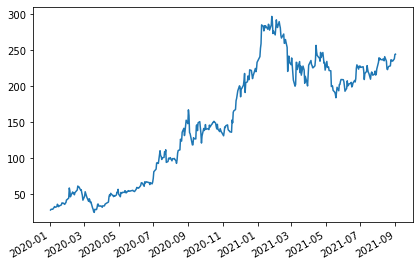

In [42]:
figure, axis = plt.subplots()
plt.tight_layout()

# formats the date index on x axis and prevents overlap
figure.autofmt_xdate()
axis.plot(index, share_open.values)

In [43]:
## Datetime indexes

In [48]:
# reset index
df_tesla = df_tesla.reset_index()

In [49]:
df_tesla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2244 entries, 0 to 2243
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        2244 non-null   datetime64[ns]
 1   (Close, TSLA)   2244 non-null   float64       
 2   (High, TSLA)    2244 non-null   float64       
 3   (Low, TSLA)     2244 non-null   float64       
 4   (Open, TSLA)    2244 non-null   float64       
 5   (Volume, TSLA)  2244 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 105.3 KB


In [52]:
df_tesla.set_index('Date', drop=True, inplace=True)

In [53]:
df_tesla

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-01-03,14.466000,14.688667,14.064000,14.324000,88849500
2017-01-04,15.132667,15.200000,14.287333,14.316667,168202500
2017-01-05,15.116667,15.165333,14.796667,15.094667,88675500
2017-01-06,15.267333,15.354000,15.030000,15.128667,82918500
2017-01-09,15.418667,15.461333,15.200000,15.264667,59692500
...,...,...,...,...,...
2025-11-28,430.170013,432.929993,426.200012,426.589996,36252900
2025-12-01,430.140015,433.660004,425.290009,425.320007,57463600


## Time Resampling

In [54]:
## datetime
from datetime import datetime